In [1]:
import numpy as np
import matplotlib.pyplot as plt

import constants
import vertical_profile as vp
import heterostructure_models.dot_2d as d2

No alloy disorder

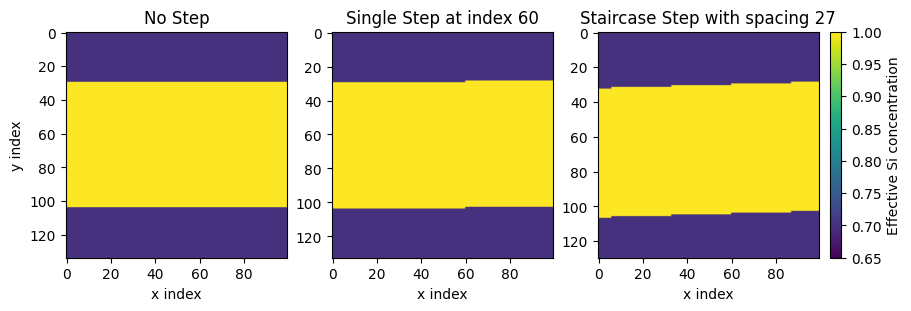

In [2]:
prof = vp.VerticalProfile(interface_type='sharp', top_cap_width_nm=4, bot_cap_width_nm=4)

lat_nostep = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='none', disorder_model='none').effective_lattice

step_ind = 60
lat_step = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='single-step', disorder_model='none', step_position_index=step_ind).effective_lattice

step_spacing = 27
lat_stair = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='staircase', disorder_model='none', step_position_index=step_ind, step_spacing=step_spacing).effective_lattice

fig, ax = plt.subplots(1, 3, figsize=(9,3), layout='constrained')
ax[0].imshow(lat_nostep.T, aspect='auto', cmap='viridis', vmin=0.65, vmax=1)
ax[0].set_title('No Step')
ax[1].imshow(lat_step.T, aspect='auto', cmap='viridis', vmin=0.65, vmax=1)
ax[1].set_title(f'Single Step at index {step_ind}')
im2 = ax[2].imshow(lat_stair.T, aspect='auto', cmap='viridis', vmin=0.65, vmax=1)
ax[2].set_title(f'Staircase Step with spacing {step_spacing}')
plt.colorbar(im2, ax=ax[2], location='right', label='Effective Si concentration')

ax[0].set_xlabel('x index')
ax[0].set_ylabel('y index')
ax[1].set_xlabel('x index')
ax[2].set_xlabel('x index')
plt.show()

Including alloy disorder

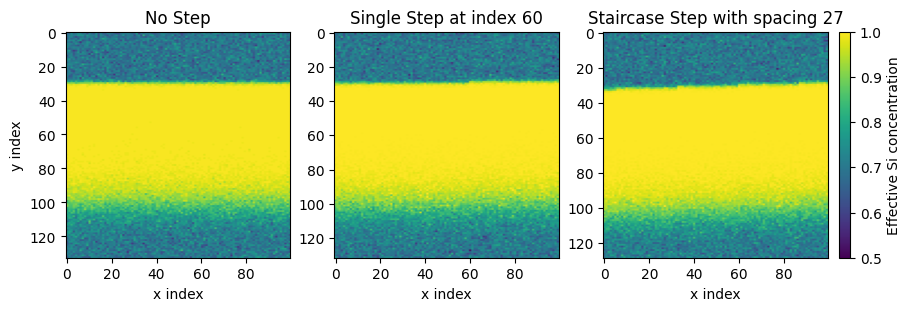

In [3]:
prof = vp.VerticalProfile(interface_type='sigmoid', top_interface_width_nm=0.3, bot_interface_width_nm=3, top_cap_width_nm=4, bot_cap_width_nm=4)

y_orb = 2e-3 # 2 meV
lat_nostep = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='none', disorder_model='alloy', y_orbital_spacing=y_orb).effective_lattice

step_ind = 60
lat_step = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='single-step', disorder_model='alloy', step_position_index=step_ind, y_orbital_spacing=y_orb).effective_lattice

step_spacing = 27
lat_stair = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='staircase', disorder_model='alloy', step_position_index=step_ind, step_spacing=step_spacing, y_orbital_spacing=y_orb).effective_lattice

fig, ax = plt.subplots(1, 3, figsize=(9,3), layout='constrained')
ax[0].imshow(lat_nostep.T, aspect='auto', cmap='viridis', vmin=0.5, vmax=1)
ax[0].set_title('No Step')
ax[1].imshow(lat_step.T, aspect='auto', cmap='viridis', vmin=0.5, vmax=1)
ax[1].set_title(f'Single Step at index {step_ind}')
im2 = ax[2].imshow(lat_stair.T, aspect='auto', cmap='viridis', vmin=0.5, vmax=1)
ax[2].set_title(f'Staircase Step with spacing {step_spacing}')
plt.colorbar(im2, ax=ax[2], location='right', label='Effective Si concentration')

ax[0].set_xlabel('x index')
ax[0].set_ylabel('y index')
ax[1].set_xlabel('x index')
ax[2].set_xlabel('x index')
plt.show()

Custom step list

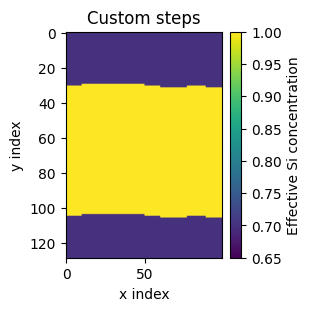

In [16]:
prof = vp.VerticalProfile(interface_type='sharp', top_cap_width_nm=4, bot_cap_width_nm=4)

# Custom step locations, directions, and offsets
sl = [10, 50, 60, 77, 89]
sd = [1, -1, -1, 1, -1]

lat = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='custom', disorder_model='none', step_location_list=sl, step_directions=sd).effective_lattice

fig, ax = plt.subplots(figsize=(3,3), layout='constrained')
im = ax.imshow(lat.T, aspect='auto', cmap='viridis', vmin=0.65, vmax=1)
ax.set_title('Custom steps')
plt.colorbar(im, ax=ax, location='right', label='Effective Si concentration')

ax.set_xlabel('x index')
ax.set_ylabel('y index')
plt.show()